# UMAP (Uniform Manifold Approximation and Projection)

UMAP ist ein nicht-linearer Dimensionalitätsreduktionsalgorithmus, der vor allem 
für die **Visualisierung hochdimensionaler Daten** verwendet wird.  
Er versucht, die **lokale Struktur der Daten** im niedrigdimensionalen Raum zu bewahren.

---

#### Grundidee

- UMAP modelliert die Daten als **Graphen**, wobei Knoten Punkte und Kanten lokale Nachbarschaften darstellen.  
- Die Einbettung in 2D oder 3D wird so optimiert, dass **nahe Punkte im Originalraum auch nahe in der Einbettung** liegen.  
- Im Gegensatz zu PCA oder linearen Methoden kann UMAP **nichtlineare Strukturen** (z. B. S-Curves, Spiralen) erkennen.

---

#### Wichtige Hyperparameter

1. **n_neighbors**  
   - Anzahl der Nachbarn, die für die lokale Struktur betrachtet werden.  
   - Kleine Werte → betonen lokale Details.  
   - Große Werte → berücksichtigen globalere Zusammenhänge.

2. **min_dist**  
   - Minimaler Abstand zwischen Punkten in der Einbettung.  
   - Kleine Werte → Clusterpunkte dichter zusammengezogen.  
   - Große Werte → Punkte weiter auseinander, mehr Platz für Struktur.

3. **n_components**  
   - Ziel-Dimension der Einbettung (typischerweise 2 für Visualisierung).

4. **random_state**  
   - Für reproduzierbare Ergebnisse.

---

#### Eigenschaften

- **UMAP ist kein Clustering-Algorithmus**.  
  - Die Einbettung zeigt die Struktur der Daten, **nicht unbedingt Klassen-Trennung**.  
  - Labels oder Cluster können sichtbar werden, wenn ähnliche Punkte nahe beieinander liegen.

- Gut geeignet für **Visualisierung von komplexen, hochdimensionalen Datensätzen** (z. B. S-Curves, MNIST, Genomdaten).

---

#### Beispiel: S-Curve Einbettung

```python
from sklearn.datasets import make_s_curve
from umap import UMAP
import matplotlib.pyplot as plt

X, t = make_s_curve(n_samples=1000, noise=0.05, random_state=42)

umap = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded = umap.fit_transform(X)

plt.scatter(X_embedded[:,0], X_embedded[:,1], c=t, cmap='Spectral')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP projection of the S-curve')
plt.colorbar(label='t')
plt.show()


In [2]:
import numpy as np
from sklearn.datasets import make_s_curve, load_iris
from umap import UMAP
import matplotlib.pyplot as plt

In this notebook, we will use `UMAP` on the iris dataset.

In [3]:
iris = load_iris(as_frame=False)
X = np.array(iris.data)
y = iris.target

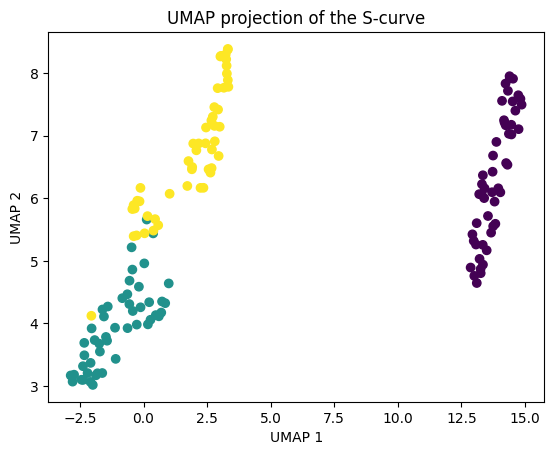

In [4]:
model = UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
            )
X_embedded = model.fit_transform(X)

plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP projection of the S-curve')
plt.show()

A different use case is to learn a representation of data distributed on a manifold. 

the `make_s_curve function` is used below. Note that the variable `t` includes an index of where precisely the data lies along the S curve, and not a label.

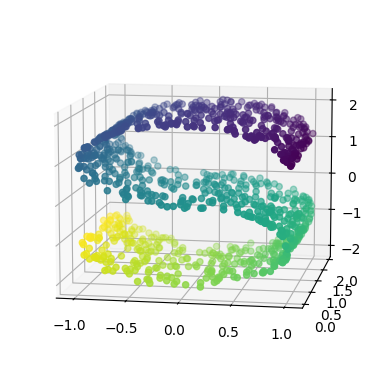

In [5]:
X,t = make_s_curve(
    n_samples=1000,
    noise=0.01,
    random_state=42
)

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=t)
ax.view_init(azim=-80, elev=10)

Try different hyperparameters: can you obtain a "better" representation? 

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


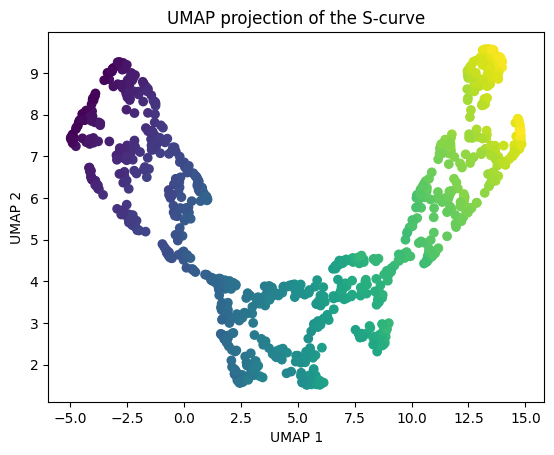

In [12]:
model = UMAP(n_neighbors=50,n_components=2,random_state=42)
X_embedded = model.fit_transform(X)

plt.scatter(X_embedded[:,0], X_embedded[:,1], c=t)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP projection of the S-curve')
plt.show()